# PV-BESS optimizer Wülknitz

### Example Jupyter notebook for scheduling a PV-BESS system using the Pyomo optimization framework.
This jupyter notebook generates schedules for the marketing of the energy provided by a combination of a PV plant and a battery storage system (BESS) and calculates the corresponding profits on the day-ahead and intraday markets (DAA, IDA and IDC).

This notebook uses historic market price data and PV production profiles and therefore represents a backtest following the principle of a perfect foresight.

The schedules are generated by functions of the scheduler_three_market.py module, which make use of the Pyomo modelling framework for mathematical opimization. Each function includes an objective and several constraints, which can be reviewed in the module.



### Imports

In [1]:
# Import necessary libraries
from scheduler_three_market_market_premium import get_daa_schedule, get_ida_schedule, get_idc_schedule # Import the scheduler module which contains the Pyomo model and optimization logic
import matplotlib.pyplot as plt  # Import matplotlib for plotting results
import pandas as pd  # Import pandas for data handling

### Set the input parameters

In [2]:
# BESS (Battery Energy Storage System) parameters
p_limit = 10.0 # 13.5  # Maximum injection power limit in MW
storage_capacity = 10 # Storage capacity in MWh
p_charge_max = 5 # Maximum charge power in MW
p_discharge_max = 5 # Maximum discharge power MW
efficiency = 0.95 # Charge/discharge efficiency of the BESS
start_soc = 0.0  # Initial state of charge
end_soc = 0.0  # End state of charge, can be adjusted as needed
number_of_cycles = 2 * 7  # Number of cycles for the period (weeks)

# General parameters
number_of_weeks = 52  # Number of weeks in the year
year = '2024'  # Year for which the data is being processed

# Commercial parameters
strike_price = 284.3 # Strike price for the plant from EEG or tender ("anzulegender Wert") in €/MWh
is_negative_price_hour_rule = False  # Flag for negative price hour rule. If set to True, market premia at negative daa price intervals are set to zero.

### Year data dictionary

In [3]:
year_data = {
             '2024': [46.24,'./data/2024/DA/2024_daa.csv',
                              './data/2024/IDA/2024_ida.csv' ,
                              './data/2024/ID1/2024_id1.csv',
                              './data/2024/PV/2024_pv.csv',
                              '2024-01-01 00:00:00'], 
             '2025': [45.08,'./data/2025/DA/2025_daa.csv',
                            './data/2025/IDA/2025_ida.csv' ,
                            './data/2025/ID1/2025_id1.csv',
                            './data/2025/PV/2025_pv.csv',
                            '2024-12-30 00:00:00']
            }
# Extract the market value (capture price) for the specified year
market_value = year_data[year][0]

### Load DAA, IDA and IDC data from files

In [4]:
daa = pd.read_csv(year_data[year][1], index_col = 0)
daa.index = pd.to_datetime(daa.index)

ida = pd.read_csv(year_data[year][2], index_col = 0)
ida.index = pd.to_datetime(ida.index)

idc = pd.read_csv(year_data[year][3], index_col = 0)
idc.index = pd.to_datetime(idc.index)

### Calculate market premium

In [5]:
market_premium = daa.copy()
market_premium.index = pd.to_datetime(market_premium.index)
market_premium['strike_price'] = strike_price
market_premium['market_value'] = market_value
market_premium['market_premium'] = market_premium['strike_price'] - market_premium['market_value']
if is_negative_price_hour_rule:
    market_premium.loc[market_premium['DAA'] < 0, 'market_premium'] = 0

### Load PV load profile from .csv:

In [6]:
pv = pd.read_csv(year_data[year][4], index_col = 0)
pv.index = pd.to_datetime(pv.index)
pv.PV = [max(0, v) for v in pv.PV] # Set negative values to zero

### Get the optimized schedule
This is done for weekly time slices. The results for the single weeks are then concatenated into a result dataframe.   

In [7]:
start = pd.to_datetime(year_data[year][5])
end = start + pd.DateOffset(days=7) - pd.DateOffset(minutes=15)  # Set end to the next week minus 15 minutes
result_list = []

for i in range(1, number_of_weeks + 1):
    print('start/end', start, end)
    pv_vector = pv.PV[start:end].to_list()
    daa_price_vector = daa.DAA[start:end].to_list()
    ida_price_vector = ida.IDA[start:end].to_list()
    idc_price_vector = idc.ID1[start:end].to_list()
    market_premium_vector = market_premium.market_premium[start:end].to_list()
    print('PV vector length:', len(pv_vector), 
          'DAA price vector length:', 
          len(daa_price_vector), 
          'IDA price vector length:', 
          len(ida_price_vector),
            'IDC price vector length:', 
            len(idc_price_vector),
          'Market Premium vector length:',
          len(market_premium_vector))

    # Ensure the vectors are not empty
    if not pv_vector or not daa_price_vector or not ida_price_vector or not idc_price_vector or not market_premium_vector:
        raise ValueError("PV output, DAA price, IDA price, IDC price, and Market Premium vectors cannot be empty.")

    # Ensure the vectors are of the same length
    if len(pv_vector) != len(daa_price_vector) or len(pv_vector) != len(ida_price_vector) or len(pv_vector) != len(idc_price_vector) or len(pv_vector) != len(market_premium_vector):
        raise ValueError("PV output, DAA price, IDA price, IDC price, and Market Premium vectors must have the same length.")

    pv_output, daa_price, market_premium_price, p_charge_daa, p_discharge_daa, soc_daa, p_curtailed_daa, injection_power_daa = get_daa_schedule(pv_vector,
                                                                                                  daa_price_vector,
                                                                                                  market_premium_vector,
                                                                                                  p_limit, 
                                                                                                  storage_capacity, 
                                                                                                  p_charge_max, 
                                                                                                  p_discharge_max, 
                                                                                                  number_of_cycles, 
                                                                                                  efficiency, 
                                                                                                  start_soc, 
                                                                                                  end_soc,
                                                                                                  )

    ida_price, p_charge_ida, p_discharge_ida, p_close_charge_daa, p_close_discharge_daa, p_curtailed_ida, \
        p_close_curtailed_daa, p_curtailed_daa_ida ,p_charge_daa_ida, p_discharge_daa_ida, soc_ida, injection_power_ida = get_ida_schedule(
                                                                                                                        ida_price_vector,
                                                                                                                        market_premium_vector,
                                                                                                                        pv_output,
                                                                                                                        p_limit, 
                                                                                                                        storage_capacity, 
                                                                                                                        p_charge_max, 
                                                                                                                        p_discharge_max,
                                                                                                                        p_charge_daa,
                                                                                                                        p_discharge_daa,
                                                                                                                        p_curtailed_daa,
                                                                                                                        number_of_cycles, 
                                                                                                                        efficiency, 
                                                                                                                        start_soc, 
                                                                                                                        end_soc)
    
    idc_price, p_charge_idc, p_discharge_idc, p_close_charge_daa_ida, p_close_discharge_daa_ida, p_curtailed_idc, \
        p_close_curtailed_daa_ida, p_curtailed_daa_ida_idc, p_charge_daa_ida_idc, p_discharge_daa_ida_idc, soc_idc, injection_power_idc = get_idc_schedule(    
                                                                                                                                idc_price_vector,
                                                                                                                                market_premium_vector,
                                                                                                                                pv_output, 
                                                                                                                                p_limit, 
                                                                                                                                storage_capacity, 
                                                                                                                                p_charge_max, 
                                                                                                                                p_discharge_max,
                                                                                                                                p_charge_daa_ida,
                                                                                                                                p_discharge_daa_ida,
                                                                                                                                p_curtailed_daa_ida,
                                                                                                                                number_of_cycles, 
                                                                                                                                efficiency, 
                                                                                                                                start_soc, 
                                                                                                                                end_soc,   
                                                                                                                            )

    # Create a DataFrame to store the results for the current week
    result = pd.DataFrame({# prices and PV output
                           'daa_price': daa_price,
                           'ida_price': ida_price,
                           'idc_price': idc_price,
                           'market_premium': market_premium_price,
                           'pv_output': pv_output,
                            # DAA results
                           'p_charge_daa': p_charge_daa,
                           'p_discharge_daa': p_discharge_daa,
                           'p_curtailed_daa': p_curtailed_daa,
                           'soc_daa': soc_daa,
                           'injection_power_daa': injection_power_daa,
                           # IDA results
                           'p_charge_ida': p_charge_ida,
                           'p_discharge_ida': p_discharge_ida,
                           'p_close_charge_daa': p_close_charge_daa,
                           'p_close_discharge_daa': p_close_discharge_daa,
                           'p_curtailed_ida': p_curtailed_ida,
                           'p_close_curtailed_daa': p_close_curtailed_daa,
                           'p_charge_daa_ida': p_charge_daa_ida,
                           'p_discharge_daa_ida': p_discharge_daa_ida,
                           'p_curtailed_daa_ida': p_curtailed_daa_ida,
                           'soc_ida': soc_ida,
                           'injection_power_ida': injection_power_ida,
                           # IDC results
                           'p_charge_idc': p_charge_idc,
                           'p_discharge_idc': p_discharge_idc,
                           'p_close_charge_daa_ida': p_close_charge_daa_ida,
                           'p_close_discharge_daa_ida': p_close_discharge_daa_ida,
                           'p_curtailed_idc': p_curtailed_idc,
                           'p_close_curtailed_daa_ida': p_close_curtailed_daa_ida,
                           'p_charge_daa_ida_idc': p_charge_daa_ida_idc,
                           'p_discharge_daa_ida_idc': p_discharge_daa_ida_idc,
                           'p_curtailed_daa_ida_idc': p_curtailed_daa_ida_idc,
                           'soc_idc': soc_idc,
                           'injection_power_idc': injection_power_idc
                          }
                         )
    
    result.index = pd.date_range(start=start, end=end, freq='15min')
    
    result_list.append(result)

    start = start + pd.DateOffset(days=7) # Set start and end to the next week
    end = end + pd.DateOffset(days=7)
    
results = pd.concat(result_list)

    

start/end 2024-01-01 00:00:00 2024-01-07 23:45:00
PV vector length: 672 DAA price vector length: 672 IDA price vector length: 672 IDC price vector length: 672 Market Premium vector length: 672
Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 8068 rows; 4705 cols; 17674 nonzeros; 1344 integer variables (1344 binary)
Coefficient ranges:
  Matrix  [5e-03, 5e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [5e-03, 1e+02]
Presolving model
4904 rows, 3757 cols, 12616 nonzeros  0s
2419 rows, 2888 cols, 7525 nonzeros  0s
2006 rows, 2442 cols, 6560 nonzeros  0s
1678 rows, 1875 cols, 4147 nonzeros  0s
613 rows, 922 cols, 1743 nonzeros  0s
613 rows, 921 cols, 1742 nonzeros  0s
Presolve reductions: rows 613(-7455); columns 921(-3784); nonzeros 1742(-15932) 

Solving MIP model with:
   613 rows
   921 cols (199 binary, 0 integer, 0 implied int., 722 continuous, 0 domain fixed)
   1742 nonzeros

Src: B => Branching; C => Central round

In [8]:
pd.set_option("display.max_columns", None)
results.head()

,daa_price,ida_price,idc_price,market_premium,pv_output,p_charge_daa,p_discharge_daa,p_curtailed_daa,soc_daa,injection_power_daa,p_charge_ida,p_discharge_ida,p_close_charge_daa,p_close_discharge_daa,p_curtailed_ida,p_close_curtailed_daa,p_charge_daa_ida,p_discharge_daa_ida,p_curtailed_daa_ida,soc_ida,injection_power_ida,p_charge_idc,p_discharge_idc,p_close_charge_daa_ida,p_close_discharge_daa_ida,p_curtailed_idc,p_close_curtailed_daa_ida,p_charge_daa_ida_idc,p_discharge_daa_ida_idc,p_curtailed_daa_ida_idc,soc_idc,injection_power_idc
2024-01-01 00:00:00,0.10,18.908018,0.950255,238.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:15:00,0.10,7.136068,-0.149025,238.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:30:00,0.10,3.224757,-2.394920,238.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:45:00,0.10,1.080706,3.409062,238.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.01,5.907751,-0.344401,238.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Plot the results

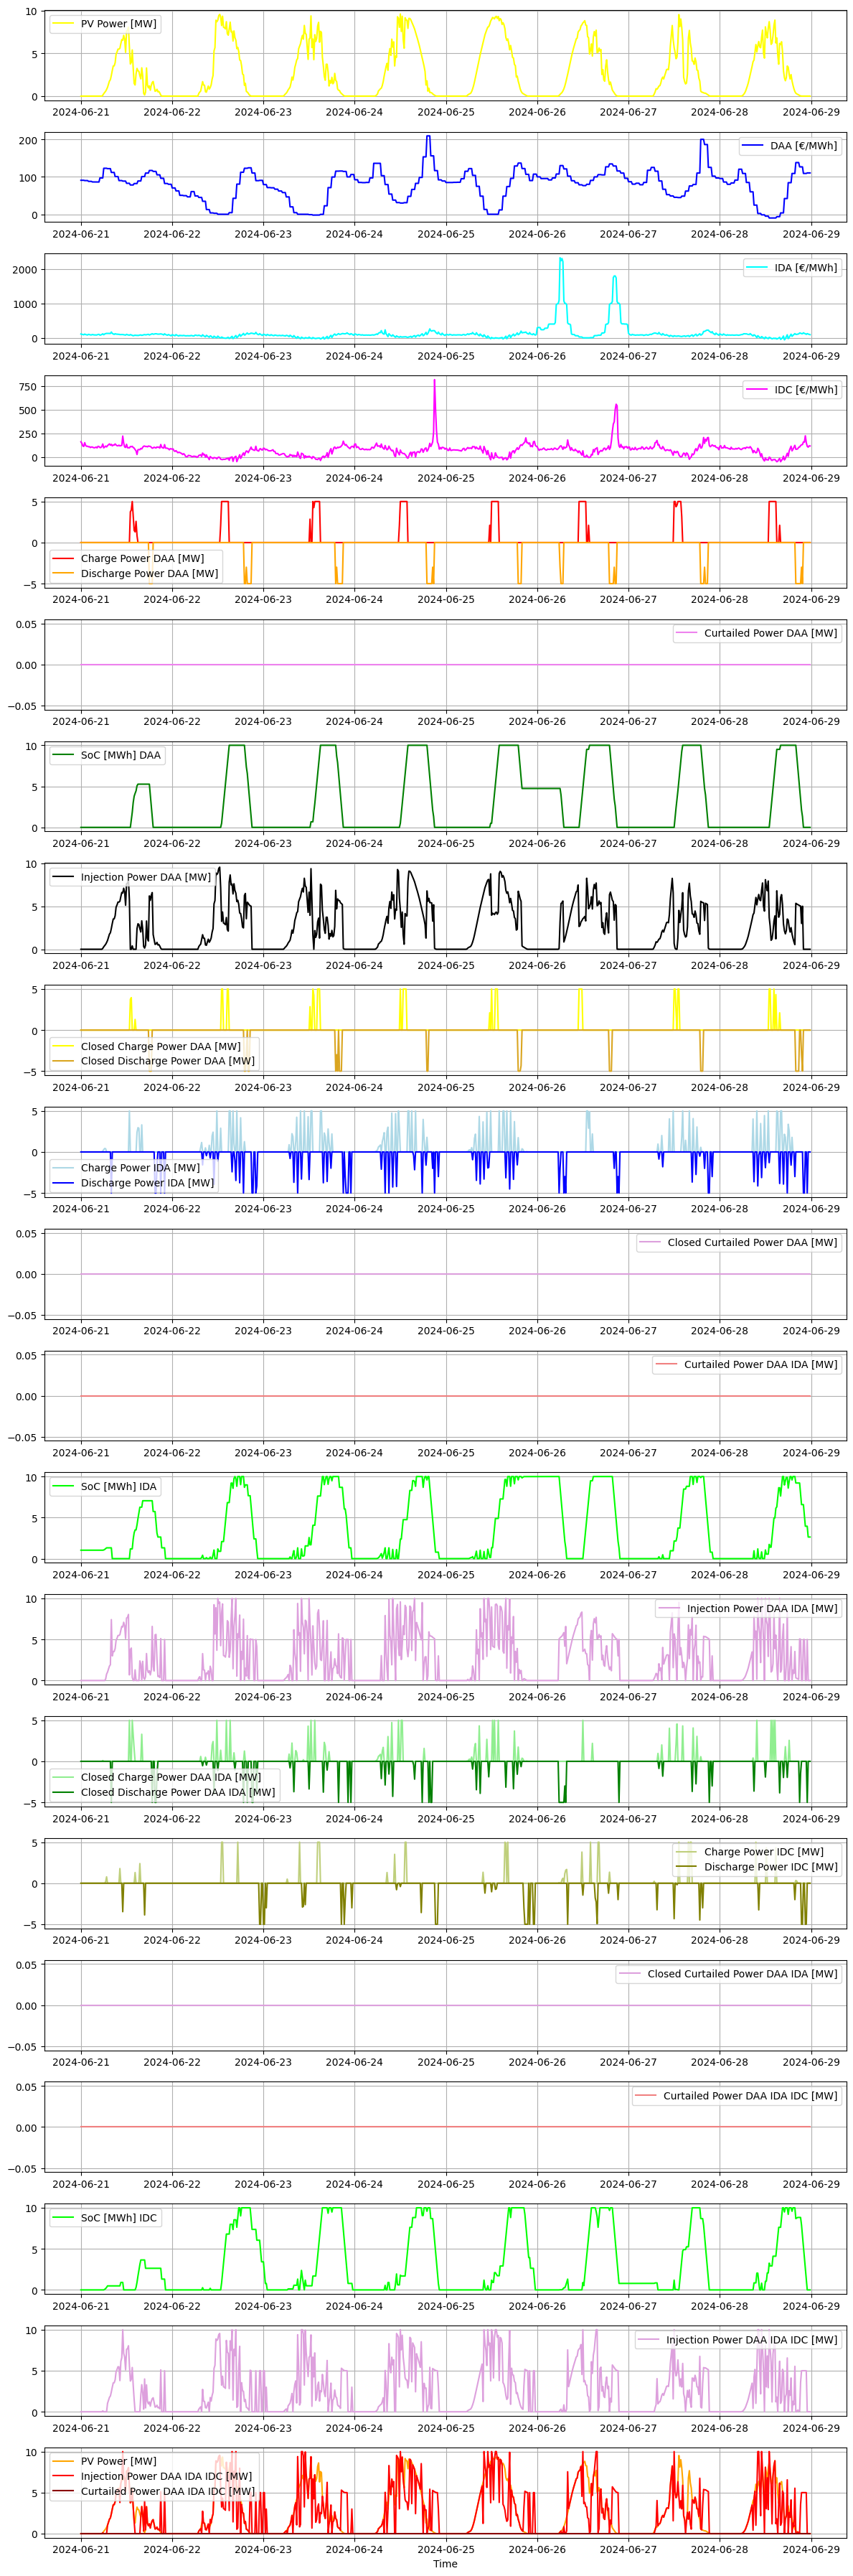

In [9]:
# Plotting the results
# Set timerange for plotting
plot_start = pd.to_datetime('2024-06-21 00:00:00')
plot_end = pd.to_datetime('2024-06-28 23:45:00')

results_slice = results[plot_start:plot_end]

fig, ax = plt.subplots(21, 1, figsize=(12,36))
ax[0].plot(results_slice.pv_output, label='PV Power [MW]', color='yellow')
ax[1].plot(results_slice.daa_price, label='DAA [€/MWh]', color='blue')
ax[2].plot(results_slice.ida_price, label='IDA [€/MWh]', color='cyan')
ax[3].plot(results_slice.idc_price, label='IDC [€/MWh]', color='magenta')
ax[4].plot(results_slice.p_charge_daa, label='Charge Power DAA [MW]', color='red')
ax[4].plot(-results_slice.p_discharge_daa, label='Discharge Power DAA [MW]', color='orange')
ax[5].plot(results_slice.p_curtailed_daa, label='Curtailed Power DAA [MW]', color='violet')
ax[6].plot(results_slice.soc_daa, label='SoC [MWh] DAA', color='green')
ax[7].plot(results_slice.injection_power_daa, label='Injection Power DAA [MW]', color='black')

ax[8].plot(results_slice.p_close_charge_daa, label='Closed Charge Power DAA [MW]', color='yellow')
ax[8].plot(-results_slice.p_close_discharge_daa, label='Closed Discharge Power DAA [MW]', color='goldenrod')
ax[9].plot(results_slice.p_charge_ida, label='Charge Power IDA [MW]', color='lightblue')
ax[9].plot(-results_slice.p_discharge_ida, label='Discharge Power IDA [MW]', color='blue')
ax[10].plot(results_slice.p_close_curtailed_daa, label='Closed Curtailed Power DAA [MW]', color='plum')
ax[11].plot(results_slice.p_curtailed_daa_ida, label='Curtailed Power DAA IDA [MW]', color='lightcoral')
ax[12].plot(results_slice.soc_ida, label='SoC [MWh] IDA', color='lime')
ax[13].plot(results_slice.injection_power_ida, label='Injection Power DAA IDA [MW]', color='plum')

ax[14].plot(results_slice.p_close_charge_daa_ida, label='Closed Charge Power DAA IDA [MW]', color='lightgreen')
ax[14].plot(-results_slice.p_close_discharge_daa_ida, label='Closed Discharge Power DAA IDA [MW]', color='green')
ax[15].plot(results_slice.p_charge_idc, label='Charge Power IDC [MW]', color='#bfcf7c')
ax[15].plot(-results_slice.p_discharge_idc, label='Discharge Power IDC [MW]', color='olive') #, ls='', marker='_')
ax[16].plot(results_slice.p_close_curtailed_daa_ida, label='Closed Curtailed Power DAA IDA [MW]', color='plum')
ax[17].plot(results_slice.p_curtailed_daa_ida_idc, label='Curtailed Power DAA IDA IDC [MW]', color='lightcoral')
ax[18].plot(results_slice.soc_idc, label='SoC [MWh] IDC', color='lime')
ax[19].plot(results_slice.injection_power_idc, label='Injection Power DAA IDA IDC [MW]', color='plum')
ax[20].plot(results_slice.pv_output, label='PV Power [MW]', color='orange')
ax[20].plot(results_slice.injection_power_idc, label='Injection Power DAA IDA IDC [MW]', color='red')
ax[20].plot(results_slice.p_curtailed_daa_ida_idc, label='Curtailed Power DAA IDA IDC [MW]', color='darkred')

ax[20].set_xlabel('Time')

for i in range(21):
    ax[i].legend()
    ax[i].grid()


plt.tight_layout()
# plt.show()
plt.savefig('results.png')

### Calculate energies and profits

In [10]:
##### Calculate pv_output considering clipping due to limited injection power
results['p_limit'] = p_limit
results['pv_output_clipped'] = results[['pv_output', 'p_limit']].min(axis=1)

##### Calculate energies
pv_production = results.pv_output.sum() * 15 / 60  # Convert from MW to MWh
injected_energy_daa = results.injection_power_daa.sum() * 15 / 60  # Convert from MW to MWh
curtailed_energy_daa = results.p_curtailed_daa.sum() * 15 / 60 # Convert from MW to MWh
discharge_energy_daa = results.p_discharge_daa.sum() * 15 / 60  # Convert from MW to MWh
charge_energy_daa = results.p_charge_daa.sum() * 15 / 60  # Convert from MW to MWh

injected_energy_ida = results.injection_power_ida.sum() * 15 / 60  # Convert from MW to MWh
curtailed_energy_ida = results.p_curtailed_daa_ida.sum() * 15 / 60 # Convert from MW to MWh
closed_curtailed_daa_energy = results.p_close_curtailed_daa.sum() * 15 / 60  # Convert from MW to MWh
discharge_energy_ida = results.p_discharge_ida.sum() * 15 / 60  # Convert from MW to MWh
charge_energy_ida = results.p_charge_ida.sum() * 15 / 60  # Convert from MW to MWh
closed_discharge_daa_energy = results.p_close_discharge_daa.sum() * 15 / 60  # Convert from MW to MWh
closed_charge_daa_energy = results.p_close_charge_daa.sum() * 15 / 60  # Convert from MW to MWh
discharge_energy_daa_ida = results.p_discharge_daa_ida.sum() * 15 / 60  # Convert from MW to MWh
charge_energy_daa_ida = results.p_charge_daa_ida.sum() * 15 / 60  # Convert from MW to MWh

injected_energy_idc = results.injection_power_idc.sum() * 15 / 60  # Convert from MW to MWh
curtailed_energy_idc = results.p_curtailed_daa_ida_idc.sum() * 15 / 60  # Convert from MW to MWh
closed_curtailed_daa_ida_energy = results.p_close_curtailed_daa_ida.sum() * 15 / 60  # Convert from MW to MWh
discharge_energy_idc = results.p_discharge_idc.sum() * 15 / 60  # Convert from MW to MWh
charge_energy_idc = results.p_charge_idc.sum() * 15 / 60  # Convert from MW to MWh
closed_discharge_daa_ida_energy = results.p_close_discharge_daa_ida.sum() * 15 / 60  # Convert from MW to MWh
closed_charge_daa_ida_energy = results.p_close_charge_daa_ida.sum() * 15 / 60  # Convert from MW to MWh
discharge_energy_daa_ida_idc = results.p_discharge_daa_ida_idc.sum() * 15 / 60  # Convert from MW to MWh
charge_energy_daa_ida_idc = results.p_charge_daa_ida_idc.sum() * 15 / 60  # Convert from MW to MWh

# Print calculated energies
print('Annual Energies:')
print('==========================================')
print('PV')
print('----------')
print('PV Production:', f'{pv_production:.2f} MWh')
print('------------------------------------------')
print('DAA Market')
print('----------')
print('Injected Energy DAA:', f'{injected_energy_daa:.2f} MWh')
print('Curtailed Energy DAA:', f'{curtailed_energy_daa:.2f} MWh')
print('Charge Energy DAA:', f'{charge_energy_daa:.2f} MWh')
print('Discharge Energy DAA:', f'{discharge_energy_daa:.2f} MWh')
print('------------------------------------------')
print('IDA Market')
print('----------')
print('Injected Energy IDA:', f'{injected_energy_ida:.2f} MWh')
print('Curtailed Energy IDA:', f'{curtailed_energy_ida:.2f} MWh')
print('Closed Curtailed Energy DAA:', f'{closed_curtailed_daa_energy:.2f} MWh')
print('Charge Energy IDA:', f'{charge_energy_ida:.2f} MWh')
print('Discharge Energy IDA:', f'{discharge_energy_ida:.2f} MWh')
print('Closed Charge Energy DAA:', f'{closed_charge_daa_energy:.2f} MWh')
print('Closed Discharge Energy DAA:', f'{closed_discharge_daa_energy:.2f} MWh')
print('Physical Charge Energy DAA IDA:', f'{charge_energy_daa_ida:.2f} MWh')
print('Physical Discharge Energy DAA IDA:', f'{discharge_energy_daa_ida:.2f} MWh')
print('------------------------------------------')
print('IDC Market')
print('----------')
print('Injected Energy IDC:', f'{injected_energy_idc:.2f} MWh')
print('Curtailed Energy IDC:', f'{curtailed_energy_idc:.2f} MWh')
print('Closed Curtailed Energy DAA IDA:', f'{closed_curtailed_daa_ida_energy:.2f} MWh')
print('Charge Energy IDC:', f'{charge_energy_idc:.2f} MWh')
print('Discharge Energy IDC:', f'{discharge_energy_idc:.2f} MWh')
print('Closed Charge Energy DAA IDA:', f'{closed_charge_daa_ida_energy:.2f} MWh')
print('Closed Discharge Energy DAA IDA:', f'{closed_discharge_daa_ida_energy:.2f} MWh')
print('Physical Charge Energy DAA IDA IDC:', f'{charge_energy_daa_ida_idc:.2f} MWh')
print('Physical Discharge Energy DAA IDA IDC:', f'{discharge_energy_daa_ida_idc:.2f} MWh')
print('------------------------------------------')

##### Calculate profits
# Calculate annual profit from PV Output multiplied with DAA prices as reference
results['pv_direct_market_profit_reference'] = results.daa_price * results.pv_output * 15 / 60
results['pv_direct_market_profit_clipped_reference'] = results.daa_price * results.pv_output_clipped * 15 / 60

if is_negative_price_hour_rule:
    # Only sum up profit at positive market prices, because plant will be curtailed at other times
    condition_daa_positive = results.daa_price >= 0

annual_pv_production = results['pv_output'].sum() * 15 / 60
annual_pv_production_clipped = results['pv_output_clipped'].sum() * 15 / 60

annual_pv_direct_market_profit_reference = results.pv_direct_market_profit_reference.sum()
annual_pv_direct_market_profit_clipped_reference = results.pv_direct_market_profit_clipped_reference.sum()

if is_negative_price_hour_rule:
    annual_pv_production_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'pv_output'].sum() * 15 / 60
    annual_pv_production_clipped_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'pv_output_clipped'].sum() * 15 / 60
    annual_pv_direct_market_profit_reference = results.loc[condition_daa_positive, 'pv_direct_market_profit_reference'].sum()
    annual_pv_direct_market_profit_clipped_reference = results.loc[condition_daa_positive, 'pv_direct_market_profit_clipped_reference'].sum()

# Calculate annual profit on DAA market
results['injected_power_direct_market_profit_daa'] = results.daa_price * results.injection_power_daa * 15 / 60
annual_injected_energy_direct_market_profit_daa = results.injected_power_direct_market_profit_daa.sum()

# Calculate annual profit on IDA market
results['ida_market_profit'] = (results['p_discharge_ida'] - results['p_charge_ida'] 
                                + results['p_close_charge_daa'] - results['p_close_discharge_daa'] 
                                + results['p_close_curtailed_daa'] - results['p_curtailed_ida']) * results['ida_price']  / 4
annual_ida_market_profit = results['ida_market_profit'].sum()

# Calculate annual profit on IDC market
results['idc_market_profit'] = (results['p_discharge_idc'] - results['p_charge_idc'] 
                                + results['p_close_charge_daa_ida'] - results['p_close_discharge_daa_ida'] 
                                + results['p_close_curtailed_daa_ida'] - results['p_curtailed_idc']) * results['idc_price']  / 4
annual_idc_market_profit = results['idc_market_profit'].sum()

# Print annual profit values
print('Annual Direct Market Profits:')
print('----------------------------------------------------------------------------------------')
if is_negative_price_hour_rule:
    print('Annual PV Direct Market Profit (Reference):', f'{annual_pv_direct_market_profit_reference:.2f} €', '(excl. negative DAA price hours)')
    print('Annual PV Direct Market Profit Clipped (Reference):', f'{annual_pv_direct_market_profit_clipped_reference:.2f} €', '(excl. negative DAA price hours)')

else:
    print('Annual PV Direct Market Profit (Reference):', f'{annual_pv_direct_market_profit_reference:.2f} €')
    print('Annual PV Direct Market Profit Clipped (Reference):', f'{annual_pv_direct_market_profit_clipped_reference:.2f} €')
print('Annual Injected Energy Direct Market Profit (DAA):', f'{annual_injected_energy_direct_market_profit_daa:.2f} €')
print('Annual IDA Market Profit:', f'{annual_ida_market_profit:.2f} €')
print('Annual IDC Market Profit:', f'{annual_idc_market_profit:.2f} €')
print('----------------------------------------------------------------------------------------')

# Calculate annual market premia
annual_injected_energy_idc = results.injection_power_idc.sum() * 15 / 60
market_premium_injected_energy_idc = annual_injected_energy_idc * (strike_price - market_value)
if is_negative_price_hour_rule:
    annual_injected_energy_idc_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'injection_power_idc'].sum() * 15 / 60
    market_premium_injected_energy_idc = annual_injected_energy_idc_excl_negative_market_price_hours * (strike_price - market_value)

if market_premium_injected_energy_idc < 0:
    market_premium_injected_energy_idc = 0

market_premium_pv_production = annual_pv_production * (strike_price - market_value)
if is_negative_price_hour_rule:
    market_premium_pv_production = annual_pv_production_excl_negative_market_price_hours * (strike_price - market_value)

if market_premium_pv_production < 0:
    market_premium_pv_production = 0

market_premium_pv_production_clipped = annual_pv_production_clipped * (strike_price - market_value)
if is_negative_price_hour_rule:
    market_premium_pv_production_clipped = annual_pv_production_clipped_excl_negative_market_price_hours * (strike_price - market_value)

if market_premium_pv_production_clipped < 0:
    market_premium_pv_production_clipped = 0

print('Annual Market Premia ():')
print('------------------------------------------------------------------')
if is_negative_price_hour_rule:
    print('Annual Market Premium PV + BESS (IDC):', f'{market_premium_injected_energy_idc:.2f} €', '(excl. negative DAA price hours)')
    print('Annual Market Premium PV only:', f'{market_premium_pv_production:.2f} €', '(excl. negative DAA price hours)')
else:
    print('Annual Market Premium PV + BESS (IDC):', f'{market_premium_injected_energy_idc:.2f} €')
    print('Annual Market Premium PV only:', f'{market_premium_pv_production:.2f} €')
print('------------------------------------------------------------------')

print('Final Results:')
print('------------------------------------------------------------')
print('Annual profit PV only (reference):', f'{market_premium_pv_production + annual_pv_direct_market_profit_reference:.2f} €')
print('Annual profit PV only clipped (reference):', f'{market_premium_pv_production_clipped + annual_pv_direct_market_profit_clipped_reference:.2f} €')

print('Annual profit PV + BESS (DAA IDA IDC):', f'{market_premium_injected_energy_idc 
                                                   + annual_injected_energy_direct_market_profit_daa 
                                                   + annual_ida_market_profit + annual_idc_market_profit:.2f} €')
print('Annual BESS profit (DAA IDA IDC):', f'{annual_injected_energy_direct_market_profit_daa + market_premium_injected_energy_idc + annual_ida_market_profit + annual_idc_market_profit
                                                   - annual_pv_direct_market_profit_clipped_reference - market_premium_pv_production_clipped:.2f} €')
print('Specific Annual BESS profit (DAA IDA IDC):', f'{(annual_injected_energy_direct_market_profit_daa + market_premium_injected_energy_idc + annual_ida_market_profit + annual_idc_market_profit
                                                   - annual_pv_direct_market_profit_clipped_reference - market_premium_pv_production_clipped) / storage_capacity:.2f} €/MWh')

Annual Energies:
PV
----------
PV Production: 12595.27 MWh
------------------------------------------
DAA Market
----------
Injected Energy DAA: 12317.85 MWh
Curtailed Energy DAA: 0.00 MWh
Charge Energy DAA: 2845.36 MWh
Discharge Energy DAA: 2567.94 MWh
------------------------------------------
IDA Market
----------
Injected Energy IDA: 12228.55 MWh
Curtailed Energy IDA: 0.00 MWh
Closed Curtailed Energy DAA: 0.00 MWh
Charge Energy IDA: 2131.81 MWh
Discharge Energy IDA: 2252.38 MWh
Closed Charge Energy DAA: 1215.88 MWh
Closed Discharge Energy DAA: 1425.76 MWh
Physical Charge Energy DAA IDA: 3761.28 MWh
Physical Discharge Energy DAA IDA: 3394.56 MWh
------------------------------------------
IDC Market
----------
Injected Energy IDC: 12221.82 MWh
Curtailed Energy IDC: 33.28 MWh
Closed Curtailed Energy DAA IDA: 0.00 MWh
Charge Energy IDC: 1156.10 MWh
Discharge Energy IDC: 1469.20 MWh
Closed Charge Energy DAA IDA: 1428.41 MWh
Closed Discharge Energy DAA IDA: 1714.96 MWh
Physical Charge En